In [32]:
#导入所需要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

In [33]:
#数据获取
filepath= './temps.csv'
features= pd.read_csv(filepath)
features.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41


In [34]:
#数据可视化，需要将year、month、day组合在一起，拼成一个字符串，然后转换成datetime格式，最后绘制出温度随时间变化的曲线图。
import datetime
# #获取年月日数据
years = features['year']
months = features['month']
days = features['day']
# #将年月日组合成一个字符串
dates=[]
for year, month, day in zip(years, months, days):
    date=str(year)+'-'+str(month)+'-'+str(day)
    dates.append(date)
#将字符串转换成datetime格式
times=[]
for date in dates:
    time=datetime.datetime.strptime(date, '%Y-%m-%d')
    times.append(time)

#看一下前5行
times[:5]

[datetime.datetime(2016, 1, 1, 0, 0),
 datetime.datetime(2016, 1, 2, 0, 0),
 datetime.datetime(2016, 1, 3, 0, 0),
 datetime.datetime(2016, 1, 4, 0, 0),
 datetime.datetime(2016, 1, 5, 0, 0)]

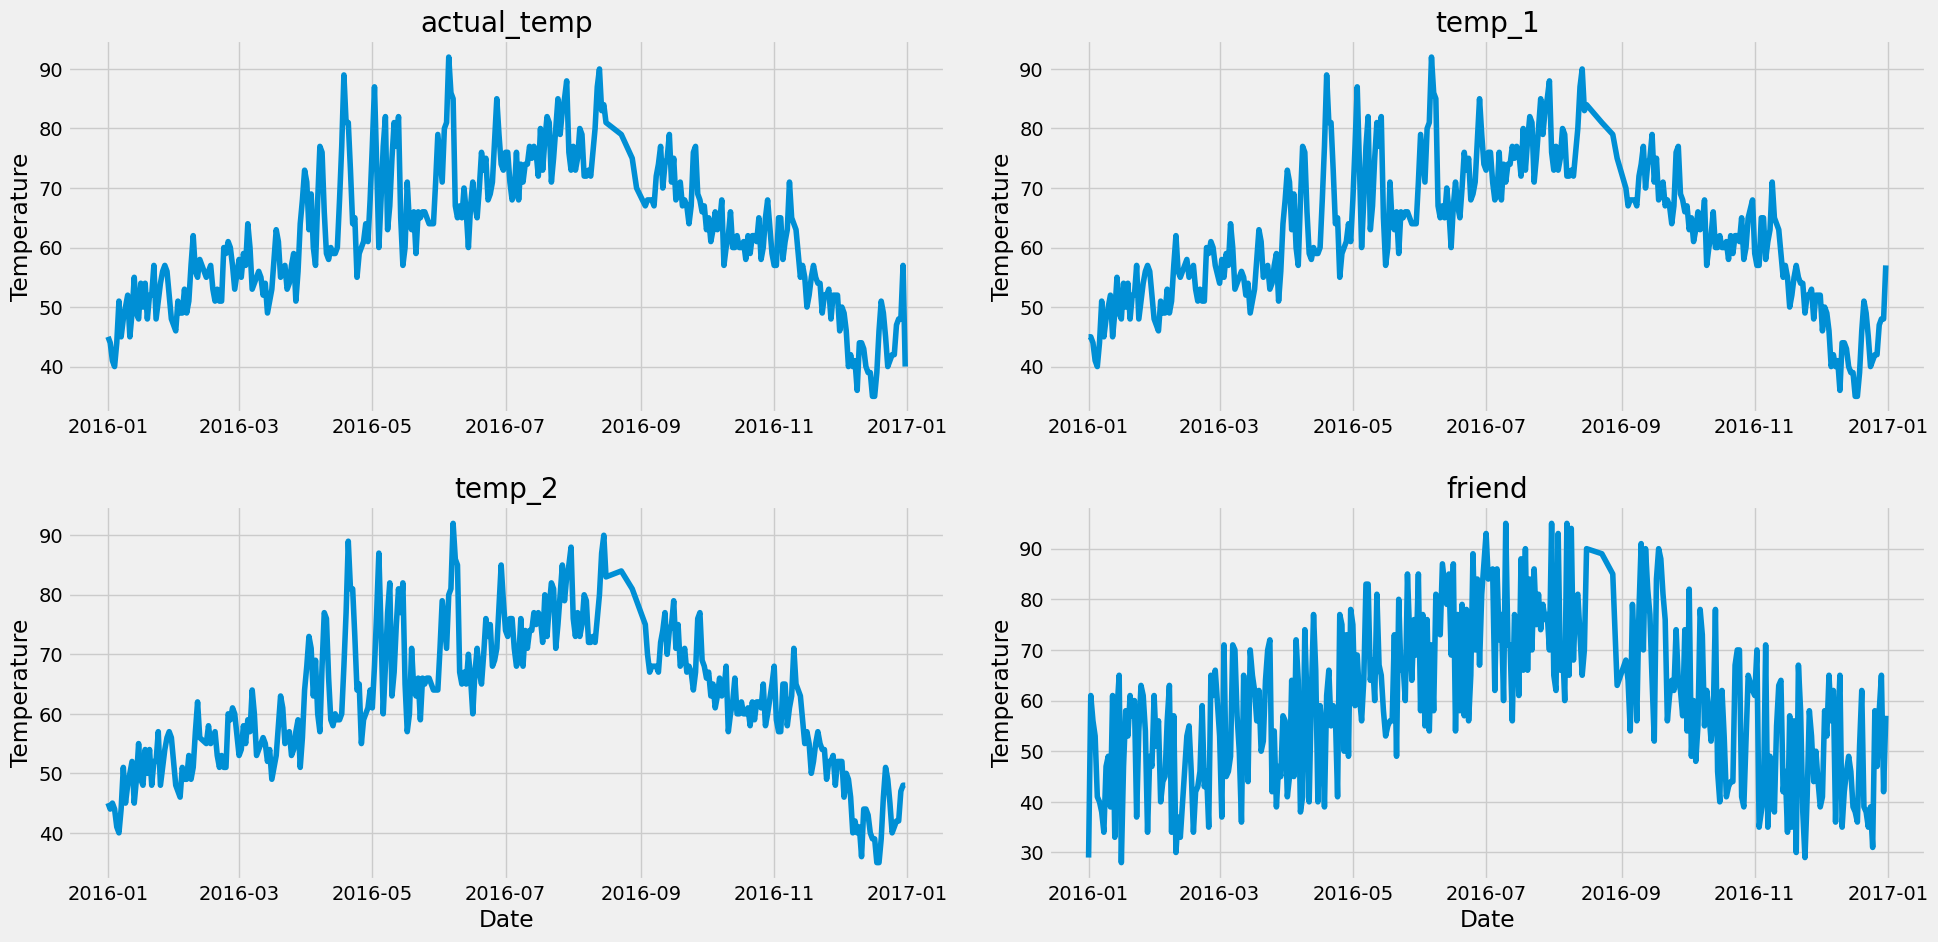

In [36]:
#可视化，对各个特征绘图
#指定绘图风格
plt.style.use('fivethirtyeight')
#设置画布，2行2列的画图窗口，第一行画ax1和ax2，第二行画ax3和ax4
fig,((ax1,ax2),(ax3,ax4))= plt.subplots(2,2,figsize=(20,10))
#==1== actual特征列
ax1.plot(times,features['actual'])
#设置x轴y轴标签和title标题
ax1.set_xlabel('');ax1.set_ylabel('Temperature');ax1.set_title('actual_temp')
#==2== 前一天的温度
ax2.plot(times,features['temp_1'])
#设置x轴y轴标签和title标题
ax2.set_xlabel('');ax2.set_ylabel('Temperature');ax2.set_title('temp_1')
#==3== 前2天的温度
ax3.plot(times,features['temp_2'])
#设置x轴y轴标签和title标题
ax3.set_xlabel('Date');ax3.set_ylabel('Temperature');ax3.set_title('temp_2')
#==4== friend
ax4.plot(times,features['friend'])
#设置x轴y轴标签和title标题
ax4.set_xlabel('Date');ax4.set_ylabel('Temperature');ax4.set_title('friend')
#轻量化布局调整绘图

plt.tight_layout(pad=2)


In [37]:
#特征处理
# 由于特征值中存在字符串类型的数据，'week'列都是字符串，因此我们需要对特征值进行one-hot编码，将字符串类型转变成数值类型

features= pd.get_dummies(features)
features = features.astype(int)
features.head(5)

#标签
labels= np.array(features['actual'])
#在特征中去掉标签
features= features.drop('actual',axis=1)
#名字单独保存一下，以备后患
features_list= list(features.columns)
#转换成合适的格式
features= np.array(features)

#处理完字符串数据以后，所有数据变成数值型。为防止由于数据单位不一，跨度大等问题导致的模型准确度不高的问题，对数值型数据进行标准化处理
from sklearn import preprocessing

input_features= preprocessing.StandardScaler().fit_transform(features)



In [38]:
#基于Keras构建网络模型
model= tf.keras.Sequential()
model.add(layers.Dense(16,kernel_initializer="random_normal",kernel_regularizer=tf.keras.regularizers.l2(0.03)))# 随机高斯分布
model.add(layers.Dense(32,kernel_initializer="random_normal",kernel_regularizer=tf.keras.regularizers.l2(0.03)))
model.add(layers.Dense(1,kernel_initializer="random_normal",kernel_regularizer=tf.keras.regularizers.l2(0.03)))
model.compile(optimizer=tf.keras.optimizers.SGD(0.001),loss="mean_squared_error")# 梯度下降，损失函数MSE
model.fit(input_features,labels,validation_split=0.25,epochs=100,batch_size=64)


Epoch 1/100
5/5 [==============================] - 0s 25ms/step - loss: 4390.9155 - val_loss: 2870.6042
Epoch 2/100
5/5 [==============================] - 0s 6ms/step - loss: 4297.2173 - val_loss: 2791.7871
Epoch 3/100
5/5 [==============================] - 0s 5ms/step - loss: 4187.2974 - val_loss: 2685.6804
Epoch 4/100
5/5 [==============================] - 0s 5ms/step - loss: 3989.6560 - val_loss: 2490.7971
Epoch 5/100
5/5 [==============================] - 0s 6ms/step - loss: 3204.1279 - val_loss: 4348.2339
Epoch 6/100
5/5 [==============================] - 0s 6ms/step - loss: 407.9491 - val_loss: 2026.8215
Epoch 7/100
5/5 [==============================] - 0s 5ms/step - loss: 82.0779 - val_loss: 1618.0262
Epoch 8/100
5/5 [==============================] - 0s 6ms/step - loss: 77.4560 - val_loss: 1128.4194
Epoch 9/100
5/5 [==============================] - 0s 5ms/step - loss: 44.8870 - val_loss: 632.7542
Epoch 10/100
5/5 [==============================] - 0s 5ms/step - loss: 88.6393 

In [41]:
model.summary() # 把整个网络模型从上到下进行展示

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 16)                240       
                                                                 
 dense_19 (Dense)            (None, 32)                544       
                                                                 
 dense_20 (Dense)            (None, 1)                 33        
                                                                 
Total params: 817 (3.19 KB)
Trainable params: 817 (3.19 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [42]:
#预测网络模型
predict= model.predict(input_features)
predict.shape

11/11 [==============================] - 0s 795us/step


(348, 1)

Text(0.5, 1.0, 'Actual and Predicted Values')

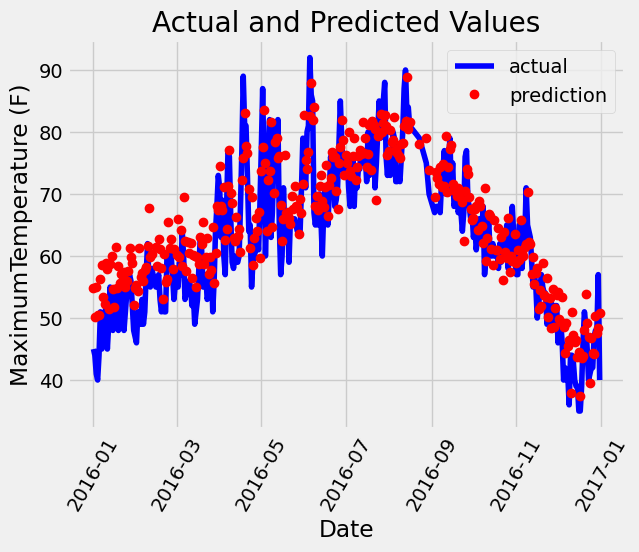

In [44]:
#测试结果并进行展示
import datetime
#datetime格式
dates= [str(int(year)) + '-' + str(int(month)) + '-' + str(int(day)) for year,month,day in zip(years,months,days)]
dates= [datetime.datetime.strptime(date,'%Y-%m-%d') for date in dates]

#创建一个表格来存日期和其对应的标签数值
true_data= pd.DataFrame(data={'date':dates,'actual':labels})
#同理，再创建一个来存日期和其对应的模型预测值
months= features[:,features_list.index('month')]
days= features[:,features_list.index('day')]
years= features[:,features_list.index('year')]
test_dates= [str(int(year)) + '-' + str(int(month)) + '-' + str(int(day)) for year,month,day in zip(years,months,days)]
test_dates= [datetime.datetime.strptime(date,'%Y-%m-%d') for date in test_dates]
predictions_data= pd.DataFrame(data ={'date':test_dates,"prediction":predict.reshape(-1)})

#真实值
plt.plot(true_data['date'],true_data['actual'],'b-',label="actual")

#预测值
plt.plot(predictions_data['date'],predictions_data['prediction'],'ro',label="prediction")
plt.xticks(rotation=60)
plt.legend()

#图名
plt.xlabel('Date')
plt.ylabel('MaximumTemperature (F)')
plt.title('Actual and Predicted Values')
